Model Selection Results:
- Baseline MSE: 2.9417
- Challenger MSE: 2.0301
Recommended Model: Random Forest (Challenger) with MSE of 2.0301


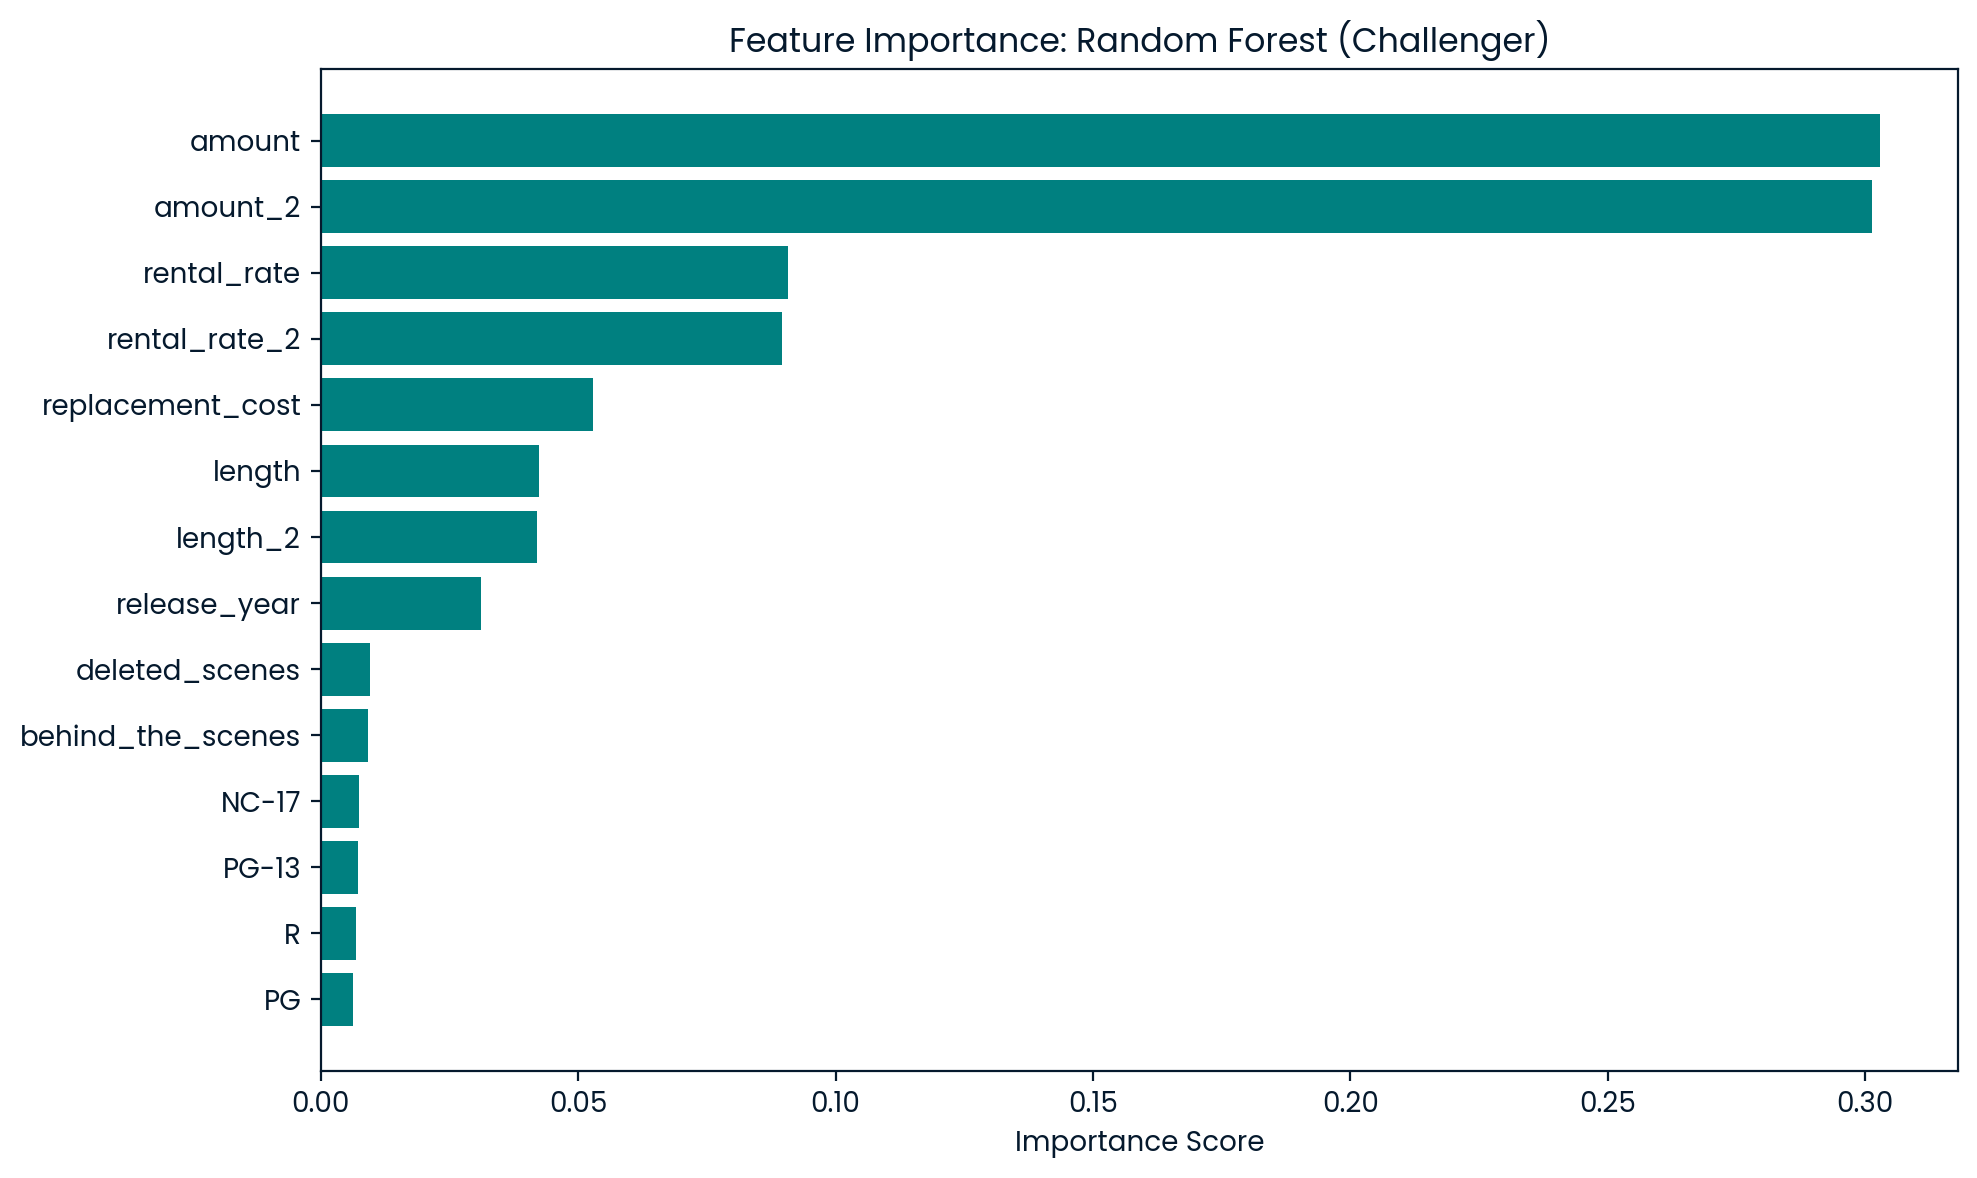

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# 1. Load the data
df = pd.read_csv('rental_info.csv')

# 2. Preprocessing
# Convert date columns to datetime objects
df['rental_date'] = pd.to_datetime(df['rental_date'])
df['return_date'] = pd.to_datetime(df['return_date'])

# Create target variable: rental_length_days
df['rental_length_days'] = (df['return_date'] - df['rental_date']).dt.days

# Create dummy variables for special features using Boolean-to-Integer conversion
df['deleted_scenes'] = df['special_features'].str.contains('Deleted Scenes').astype(int)
df['behind_the_scenes'] = df['special_features'].str.contains('Behind the Scenes').astype(int)

# Define features (X) and target (y)
# Drop original dates and text to avoid data leakage
cols_to_drop = ["rental_length_days", "rental_date", "return_date", "special_features"]
X = df.drop(columns=cols_to_drop)
y = df['rental_length_days']

# 3. Train-Test Split (20% test set, random_state=9)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=9)

# 4. Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# 5. Challenger Model: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=9)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# 6. Model Selection Logic
if mse_lr < mse_rf:
    best_model = lr
    best_mse = mse_lr
    chosen_name = "Linear Regression (Baseline)"
else:
    best_model = rf
    best_mse = mse_rf
    chosen_name = "Random Forest (Challenger)"

print(f"Model Selection Results:")
print(f"- Baseline MSE: {mse_lr:.4f}")
print(f"- Challenger MSE: {mse_rf:.4f}")
print(f"Recommended Model: {chosen_name} with MSE of {best_mse:.4f}")

# 7. Feature Importance Plot (Using the best model)
importances = rf.feature_importances_
feature_names = X.columns
fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title(f'Feature Importance: {chosen_name}')
plt.tight_layout()
plt.show()